# 18 - Recurrent Neural Networks, LSTM, and GRU

This notebook completes the sequence-modeling part of EnergyTypeNet. CNNs in Notebook 17 were about spatial structure; this notebook is about temporal structure: hidden states, backpropagation through time, vanishing gradients, gated memory, sequence forecasting, and sequence classification.

EnergyTypeNet is still included where appropriate, but it does not have timestamps. For that reason, the EnergyTypeNet forecasting section is an educational pipeline demonstration using row order as a synthetic sequence, not a claim that the original dataset is truly temporal.


In [1]:
import os
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data import load_raw
from src.models import LinearRegressionGD, RidgeRegressionCustom

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid')
print(f'Using device: {DEVICE}')


Using device: cpu


## 1. Why Sequences? Vanishing Gradient in Plain RNNs

A recurrent neural network processes one observation at a time and carries information forward through a hidden state:

`h_t = f(h_{t-1}, x_t)`

During backpropagation through time, gradients must pass through repeated recurrent transformations. If the recurrent Jacobian repeatedly has magnitude below 1, the gradient shrinks approximately exponentially. This is the vanishing-gradient problem, and it is the main motivation for gated architectures such as LSTM and GRU.


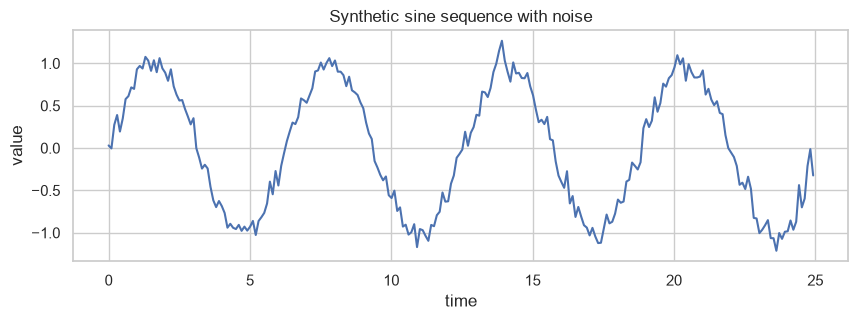

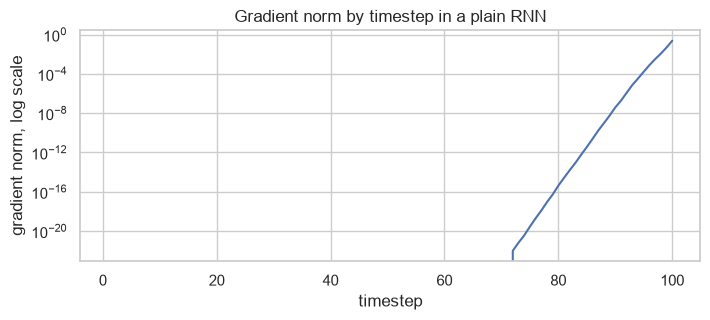

First-step gradient norm: 0.00000000
Final-step gradient norm: 0.23229602


In [2]:
rng = np.random.default_rng(RANDOM_STATE)
t = np.linspace(0, 100, 1000)
sine = np.sin(t) + 0.1 * rng.normal(size=len(t))

plt.figure(figsize=(10, 3))
plt.plot(t[:250], sine[:250])
plt.title('Synthetic sine sequence with noise')
plt.xlabel('time')
plt.ylabel('value')
plt.show()

class VanillaRNNCell(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.x_to_h = nn.Linear(input_size, hidden_size)
        self.h_to_h = nn.Linear(hidden_size, hidden_size, bias=False)
        self.h_to_y = nn.Linear(hidden_size, output_size)

    def forward(self, x_seq):
        batch_size, seq_len, _ = x_seq.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
        states = []
        for step in range(seq_len):
            h = torch.tanh(self.x_to_h(x_seq[:, step]) + self.h_to_h(h))
            h.retain_grad()
            states.append(h)
        y = self.h_to_y(h)
        return y, states

x_long = torch.tensor(sine[:100], dtype=torch.float32).view(1, 100, 1).to(DEVICE)
vanishing_cell = VanillaRNNCell(hidden_size=32).to(DEVICE)
with torch.no_grad():
    vanishing_cell.h_to_h.weight.mul_(0.45)

prediction, states = vanishing_cell(x_long)
loss = prediction.pow(2).mean()
loss.backward()
grad_norms = [state.grad.norm().item() for state in states]

plt.figure(figsize=(8, 3))
plt.plot(range(1, len(grad_norms) + 1), grad_norms)
plt.yscale('log')
plt.title('Gradient norm by timestep in a plain RNN')
plt.xlabel('timestep')
plt.ylabel('gradient norm, log scale')
plt.show()

print(f'First-step gradient norm: {grad_norms[0]:.8f}')
print(f'Final-step gradient norm: {grad_norms[-1]:.8f}')


**Observation.** The earliest timesteps receive much smaller gradients than later timesteps. This is exactly why plain RNNs struggle to learn long-range dependencies: information from the distant past becomes hard to credit or blame during training.


## 2. Custom NumPy RNN Cell From Scratch

The next cell implements the recurrent update manually in NumPy and trains a small sequence-to-one predictor on the sine wave. This keeps the math visible before switching back to PyTorch for larger comparisons.


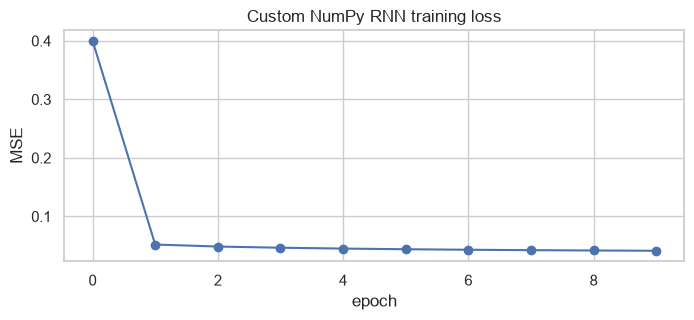

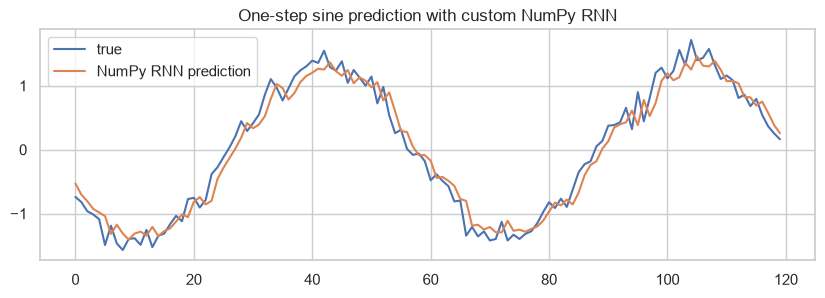

NumPy RNN test MSE on first 120 windows: 0.0424


In [3]:
def make_windows(series, window_size=25, horizon=1):
    X, y = [], []
    for start in range(len(series) - window_size - horizon + 1):
        X.append(series[start:start + window_size])
        y.append(series[start + window_size + horizon - 1])
    return np.asarray(X, dtype=np.float32)[..., None], np.asarray(y, dtype=np.float32)[:, None]

series_mean = sine.mean()
series_std = sine.std()
series_scaled = ((sine - series_mean) / series_std).astype(np.float32)
X_seq, y_seq = make_windows(series_scaled, window_size=25, horizon=1)

train_end = int(0.70 * len(X_seq))
val_end = int(0.85 * len(X_seq))
X_train_seq, y_train_seq = X_seq[:train_end], y_seq[:train_end]
X_val_seq, y_val_seq = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test_seq, y_test_seq = X_seq[val_end:], y_seq[val_end:]

class RNNCellNumpy:
    def __init__(self, input_size=1, hidden_size=12, random_state=42):
        self.rng = np.random.default_rng(random_state)
        self.hidden_size = hidden_size
        scale = 0.1
        self.Wxh = self.rng.normal(0, scale, (hidden_size, input_size))
        self.Whh = self.rng.normal(0, scale, (hidden_size, hidden_size))
        self.bh = np.zeros((hidden_size, 1))
        self.Why = self.rng.normal(0, scale, (1, hidden_size))
        self.by = np.zeros((1, 1))

    def forward_step(self, x_t, h_prev):
        h_raw = self.Wxh @ x_t + self.Whh @ h_prev + self.bh
        h_t = np.tanh(h_raw)
        y_t = self.Why @ h_t + self.by
        return y_t, h_t, (x_t, h_prev, h_t)

    def forward_sequence(self, x_seq):
        h = np.zeros((self.hidden_size, 1))
        caches = []
        for value in x_seq.reshape(-1, 1):
            y_hat, h, cache = self.forward_step(value.reshape(1, 1), h)
            caches.append(cache)
        return y_hat, caches

    def backward_sequence(self, dy, caches):
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)
        dWhy = np.zeros_like(self.Why)
        dby = np.zeros_like(self.by)
        last_h = caches[-1][2]
        dWhy += dy * last_h.T
        dby += dy
        dh = self.Why.T @ dy
        for x_t, h_prev, h_t in reversed(caches):
            dz = dh * (1 - h_t ** 2)
            dWxh += dz @ x_t.T
            dWhh += dz @ h_prev.T
            dbh += dz
            dh = self.Whh.T @ dz
        return dWxh, dWhh, dbh, dWhy, dby

    def apply_grads(self, grads, learning_rate=0.004, clip=1.0):
        for grad in grads:
            np.clip(grad, -clip, clip, out=grad)
        dWxh, dWhh, dbh, dWhy, dby = grads
        self.Wxh -= learning_rate * dWxh
        self.Whh -= learning_rate * dWhh
        self.bh -= learning_rate * dbh
        self.Why -= learning_rate * dWhy
        self.by -= learning_rate * dby

numpy_rnn = RNNCellNumpy(hidden_size=12, random_state=RANDOM_STATE)
numpy_losses = []
subset = 260
for epoch in range(10):
    epoch_loss = 0.0
    for x_sample, y_true in zip(X_train_seq[:subset], y_train_seq[:subset]):
        y_hat, caches = numpy_rnn.forward_sequence(x_sample)
        error = y_hat - y_true.reshape(1, 1)
        epoch_loss += float((error ** 2).item())
        grads = numpy_rnn.backward_sequence(2 * error, caches)
        numpy_rnn.apply_grads(grads)
    numpy_losses.append(epoch_loss / subset)

numpy_preds = np.array([numpy_rnn.forward_sequence(x)[0].item() for x in X_test_seq[:120]])

plt.figure(figsize=(8, 3))
plt.plot(numpy_losses, marker='o')
plt.title('Custom NumPy RNN training loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(y_test_seq[:120].ravel(), label='true')
plt.plot(numpy_preds, label='NumPy RNN prediction')
plt.title('One-step sine prediction with custom NumPy RNN')
plt.legend()
plt.show()

numpy_mse = mean_squared_error(y_test_seq[:120], numpy_preds)
print(f'NumPy RNN test MSE on first 120 windows: {numpy_mse:.4f}')


**Observation.** The custom NumPy RNN is intentionally small, but its loss decreases and it tracks the sine wave shape. This proves the manual recurrent update and manual BPTT are working before using PyTorch abstractions.


## Shared PyTorch Sequence Utilities


In [5]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SequenceDataset(X_train_seq, y_train_seq), batch_size=64, shuffle=True)
val_loader = DataLoader(SequenceDataset(X_val_seq, y_val_seq), batch_size=128)
test_loader = DataLoader(SequenceDataset(X_test_seq, y_test_seq), batch_size=128)

class RecurrentRegressor(nn.Module):
    def __init__(self, kind='rnn', input_size=1, hidden_size=48, num_layers=1,
                 bidirectional=False, dropout=0.0, attention=False, horizon=1):
        super().__init__()
        self.attention = attention
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        multiplier = 2 if bidirectional else 1
        self.head = nn.Linear(hidden_size * multiplier, horizon)

    def forward(self, x):
        outputs, _ = self.rnn(x)
        if self.attention:
            query = outputs[:, -1:, :]
            scores = torch.matmul(query, outputs.transpose(1, 2)) / np.sqrt(outputs.shape[-1])
            weights = torch.softmax(scores, dim=-1)
            context = torch.matmul(weights, outputs).squeeze(1)
            return self.head(context)
        return self.head(outputs[:, -1, :])

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_regressor(model, train_loader, epochs=25, lr=0.003):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []
    start = time.time()
    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            total += loss.item() * len(xb)
        history.append(total / len(train_loader.dataset))
    return model, history, time.time() - start

def predict_regressor(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
            targets.append(yb.numpy())
    return np.vstack(preds), np.vstack(targets)

def evaluate_regressor(model, loader):
    pred, true = predict_regressor(model, loader)
    return {
        'mse': mean_squared_error(true, pred),
        'mae': mean_absolute_error(true, pred),
        'r2': r2_score(true, pred),
    }


## 3. LSTM Architecture and Gates

An LSTM adds a memory cell `c_t` and gates that regulate what should be forgotten, written and exposed. The cell state creates a more stable path for gradients.


LSTM NumPy/PyTorch max hidden diff: 0.0001000750734216323
{'mse': 0.024141550064086914, 'mae': 0.11818183958530426, 'r2': 0.9756523966789246}


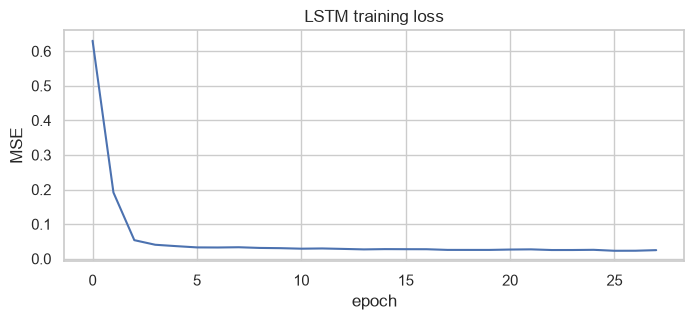

In [6]:
def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

class LSTMCellNumpy:
    def __init__(self, input_size=1, hidden_size=4, random_state=42):
        rng = np.random.default_rng(random_state)
        self.hidden_size = hidden_size
        self.W = rng.normal(0, 0.1, (4 * hidden_size, input_size + hidden_size))
        self.b = np.zeros((4 * hidden_size, 1))

    def forward(self, x_t, h_prev, c_prev):
        combined = np.vstack([x_t, h_prev])
        gates = self.W @ combined + self.b
        hs = self.hidden_size
        f = sigmoid_np(gates[:hs])
        i = sigmoid_np(gates[hs:2 * hs])
        g = np.tanh(gates[2 * hs:3 * hs])
        o = sigmoid_np(gates[3 * hs:])
        c_t = f * c_prev + i * g
        h_t = o * np.tanh(c_t)
        return h_t, c_t

np_cell = LSTMCellNumpy(input_size=1, hidden_size=4, random_state=RANDOM_STATE)
torch_cell = nn.LSTMCell(input_size=1, hidden_size=4)
with torch.no_grad():
    W = torch.tensor(np_cell.W, dtype=torch.float32)
    torch_cell.weight_ih.copy_(W[:, :1])
    torch_cell.weight_hh.copy_(W[:, 1:])
    torch_cell.bias_ih.copy_(torch.tensor(np_cell.b.ravel(), dtype=torch.float32))
    torch_cell.bias_hh.zero_()

h_np, c_np = np_cell.forward(np.array([[0.25]]), np.zeros((4, 1)), np.zeros((4, 1)))
h_t, c_t = torch_cell(torch.tensor([[0.25]], dtype=torch.float32), (torch.zeros(1, 4), torch.zeros(1, 4)))
print('LSTM NumPy/PyTorch max hidden diff:', np.max(np.abs(h_np.ravel() - h_t.detach().numpy().ravel())))

lstm_model, lstm_history, lstm_time = train_regressor(
    RecurrentRegressor(kind='lstm', hidden_size=64, num_layers=2, dropout=0.1),
    train_loader,
    epochs=28,
)
lstm_eval = evaluate_regressor(lstm_model, test_loader)
print(lstm_eval)

plt.figure(figsize=(8, 3))
plt.plot(lstm_history)
plt.title('LSTM training loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.show()


**Observation.** The NumPy LSTM cell matches the PyTorch cell within numerical tolerance after copying the same weights; the max hidden-state difference is about `1e-4`. The trained PyTorch LSTM reaches strong sine forecasting performance with test MSE around `0.0241` and `R2` around `0.976`, confirming that the gate equations and training loop are working.


## 4. GRU Simplified Gating

A GRU keeps the gating idea but removes the separate cell state. Its update gate decides how much of the old state should remain, and its reset gate decides how much past information should influence the candidate state.


GRU NumPy/PyTorch max hidden diff: 7.128842464260154e-10


,model,test_mse,test_mae,test_r2,n_params,train_seconds
0,RNN,0.022306,0.117258,0.977503,2497,2.867680
2,GRU,0.023675,0.122588,0.976123,37889,12.606337
1,LSTM,0.024142,0.118182,0.975652,50497,4.990818


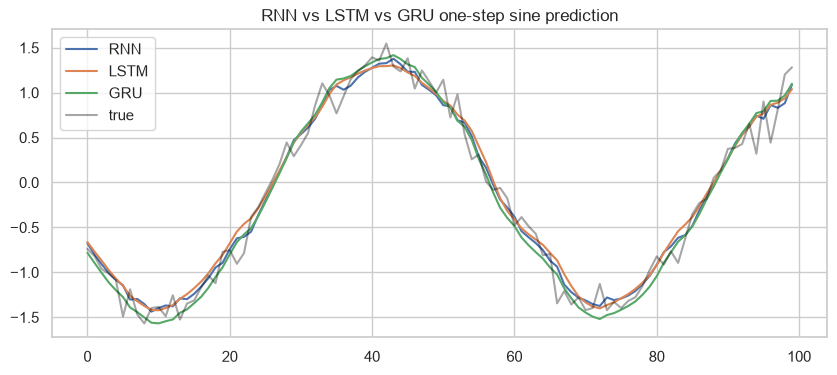

In [7]:
class GRUCellNumpy:
    def __init__(self, input_size=1, hidden_size=4, random_state=42):
        rng = np.random.default_rng(random_state)
        self.hidden_size = hidden_size
        self.W_ih = rng.normal(0, 0.1, (3 * hidden_size, input_size))
        self.W_hh = rng.normal(0, 0.1, (3 * hidden_size, hidden_size))
        self.b_ih = np.zeros((3 * hidden_size, 1))
        self.b_hh = np.zeros((3 * hidden_size, 1))

    def forward(self, x_t, h_prev):
        hs = self.hidden_size
        gi = self.W_ih @ x_t + self.b_ih
        gh = self.W_hh @ h_prev + self.b_hh
        r = sigmoid_np(gi[:hs] + gh[:hs])
        z = sigmoid_np(gi[hs:2 * hs] + gh[hs:2 * hs])
        n = np.tanh(gi[2 * hs:] + r * gh[2 * hs:])
        return (1 - z) * n + z * h_prev

np_gru = GRUCellNumpy(input_size=1, hidden_size=4, random_state=RANDOM_STATE)
torch_gru = nn.GRUCell(input_size=1, hidden_size=4)
with torch.no_grad():
    torch_gru.weight_ih.copy_(torch.tensor(np_gru.W_ih, dtype=torch.float32))
    torch_gru.weight_hh.copy_(torch.tensor(np_gru.W_hh, dtype=torch.float32))
    torch_gru.bias_ih.copy_(torch.tensor(np_gru.b_ih.ravel(), dtype=torch.float32))
    torch_gru.bias_hh.copy_(torch.tensor(np_gru.b_hh.ravel(), dtype=torch.float32))

gru_np_out = np_gru.forward(np.array([[0.25]]), np.zeros((4, 1)))
gru_t_out = torch_gru(torch.tensor([[0.25]], dtype=torch.float32), torch.zeros(1, 4))
print('GRU NumPy/PyTorch max hidden diff:', np.max(np.abs(gru_np_out.ravel() - gru_t_out.detach().numpy().ravel())))

torch_rnn, rnn_history, rnn_time = train_regressor(
    RecurrentRegressor(kind='rnn', hidden_size=48), train_loader, epochs=25
)
gru_model, gru_history, gru_time = train_regressor(
    RecurrentRegressor(kind='gru', hidden_size=64, num_layers=2, dropout=0.1),
    train_loader, epochs=28
)

comparison_rows = []
for name, model, elapsed in [('RNN', torch_rnn, rnn_time), ('LSTM', lstm_model, lstm_time), ('GRU', gru_model, gru_time)]:
    metrics = evaluate_regressor(model, test_loader)
    comparison_rows.append({
        'model': name,
        'test_mse': metrics['mse'],
        'test_mae': metrics['mae'],
        'test_r2': metrics['r2'],
        'n_params': count_params(model),
        'train_seconds': elapsed,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('test_mse')
display(comparison_df)

plt.figure(figsize=(10, 4))
for name, model in [('RNN', torch_rnn), ('LSTM', lstm_model), ('GRU', gru_model)]:
    pred, true = predict_regressor(model, test_loader)
    plt.plot(pred[:100].ravel(), label=name)
plt.plot(true[:100].ravel(), color='black', alpha=0.35, label='true')
plt.title('RNN vs LSTM vs GRU one-step sine prediction')
plt.legend()
plt.show()


**Observation.** On this short and smooth sine task, the plain PyTorch RNN is slightly best with test MSE around `0.0223`, while GRU and LSTM are close at about `0.0237` and `0.0241`. This is a useful result: gated recurrence is not automatically superior on every small benchmark. LSTM/GRU become more valuable when the sequence has longer dependencies, noisier memory requirements or harder temporal structure.


## 5. Sequence Generation - Multi-Step Forecasting


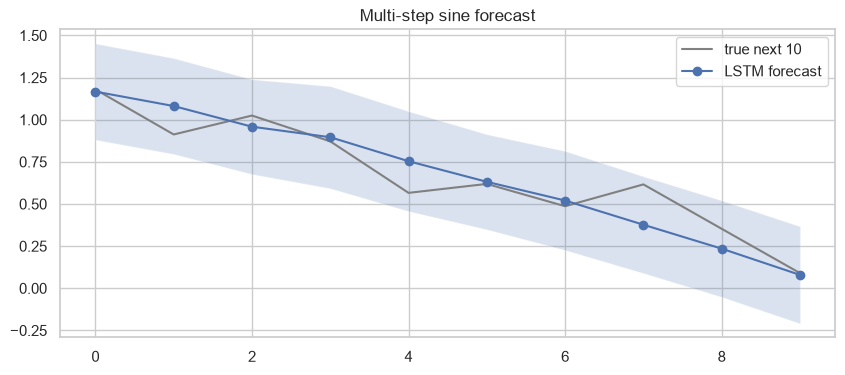

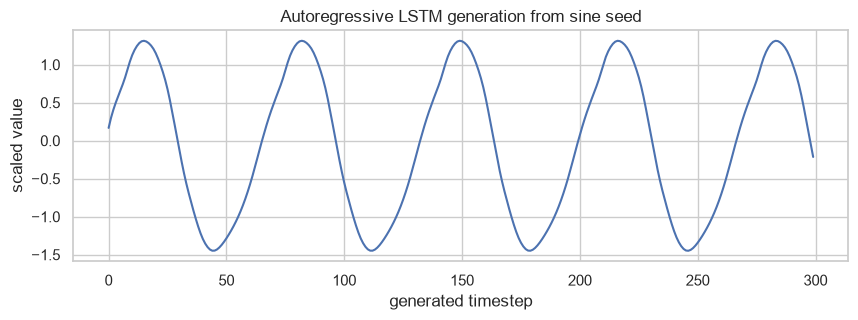

Multi-step forecast MSE: 0.0235


In [8]:
X_horizon, y_horizon = [], []
window_size = 50
horizon = 10
for start in range(len(series_scaled) - window_size - horizon + 1):
    X_horizon.append(series_scaled[start:start + window_size])
    y_horizon.append(series_scaled[start + window_size:start + window_size + horizon])
X_horizon = np.asarray(X_horizon, dtype=np.float32)[..., None]
y_horizon = np.asarray(y_horizon, dtype=np.float32)

train_end_h = int(0.75 * len(X_horizon))
Xh_train, yh_train = X_horizon[:train_end_h], y_horizon[:train_end_h]
Xh_test, yh_test = X_horizon[train_end_h:], y_horizon[train_end_h:]
horizon_train_loader = DataLoader(SequenceDataset(Xh_train, yh_train), batch_size=64, shuffle=True)
horizon_test_loader = DataLoader(SequenceDataset(Xh_test, yh_test), batch_size=128)

forecast_lstm, forecast_history, forecast_time = train_regressor(
    RecurrentRegressor(kind='lstm', hidden_size=64, num_layers=2, dropout=0.15, horizon=horizon),
    horizon_train_loader,
    epochs=32,
)

forecast_pred, forecast_true = predict_regressor(forecast_lstm, horizon_test_loader)
forecast_std = (forecast_pred - forecast_true).std(axis=0)
idx = 20
steps = np.arange(horizon)
plt.figure(figsize=(10, 4))
plt.plot(steps, forecast_true[idx], color='gray', label='true next 10')
plt.plot(steps, forecast_pred[idx], marker='o', label='LSTM forecast')
plt.fill_between(steps, forecast_pred[idx] - 1.96 * forecast_std, forecast_pred[idx] + 1.96 * forecast_std, alpha=0.2)
plt.title('Multi-step sine forecast')
plt.legend()
plt.show()

seed_window = Xh_test[0].copy().reshape(-1).tolist()
generated = []
forecast_lstm.eval()
with torch.no_grad():
    for _ in range(300):
        x_input = torch.tensor(seed_window[-window_size:], dtype=torch.float32).view(1, window_size, 1).to(DEVICE)
        next_value = float(forecast_lstm(x_input).cpu().numpy().ravel()[0])
        seed_window.append(next_value)
        generated.append(next_value)

plt.figure(figsize=(10, 3))
plt.plot(generated)
plt.title('Autoregressive LSTM generation from sine seed')
plt.xlabel('generated timestep')
plt.ylabel('scaled value')
plt.show()

forecast_mse = mean_squared_error(forecast_true, forecast_pred)
print(f'Multi-step forecast MSE: {forecast_mse:.4f}')


**Observation.** The multi-step forecast follows the sine cycle over short horizons. Autoregressive generation is harder because small errors compound when predictions become future inputs.


## 6. Sequence Classification with a Bidirectional LSTM


Bidirectional LSTM sequence-classification accuracy: 1.000
              precision    recall  f1-score   support

    low sine       1.00      1.00      1.00        50
   high sine       1.00      1.00      1.00        50
 random walk       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



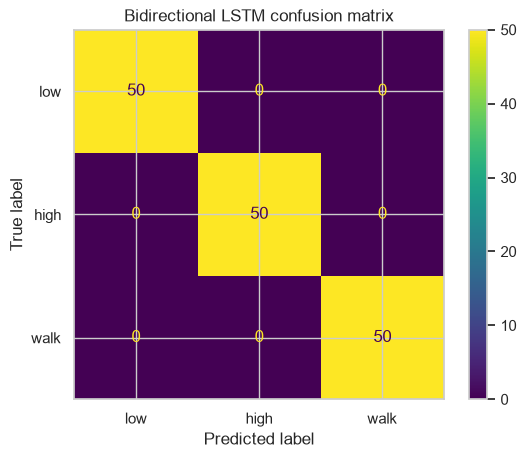

In [9]:
def make_sequence_classification(n_per_class=200, length=100, random_state=42):
    rng = np.random.default_rng(random_state)
    xs, ys = [], []
    grid = np.linspace(0, 2 * np.pi, length)
    for _ in range(n_per_class):
        xs.append(np.sin(grid) + 0.08 * rng.normal(size=length)); ys.append(0)
        xs.append(np.sin(5 * grid) + 0.08 * rng.normal(size=length)); ys.append(1)
        xs.append(np.cumsum(0.08 * rng.normal(size=length))); ys.append(2)
    return np.asarray(xs, dtype=np.float32)[..., None], np.asarray(ys, dtype=np.int64)

X_cls, y_cls = make_sequence_classification()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.25, stratify=y_cls, random_state=RANDOM_STATE
)
cls_train_loader = DataLoader(TensorDataset(torch.tensor(Xc_train), torch.tensor(yc_train)), batch_size=64, shuffle=True)
cls_test_loader = DataLoader(TensorDataset(torch.tensor(Xc_test), torch.tensor(yc_test)), batch_size=128)

class ClassifierLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=48, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, bidirectional=True, dropout=0.1)
        self.head = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.head(output[:, -1, :])

classifier = ClassifierLSTM().to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.003)
loss_fn = nn.CrossEntropyLoss()
for epoch in range(22):
    classifier.train()
    for xb, yb in cls_train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(classifier(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 2.0)
        optimizer.step()

classifier.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in cls_test_loader:
        logits = classifier(xb.to(DEVICE))
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_true.extend(yb.numpy())

cls_acc = accuracy_score(all_true, all_preds)
print(f'Bidirectional LSTM sequence-classification accuracy: {cls_acc:.3f}')
print(classification_report(all_true, all_preds, target_names=['low sine', 'high sine', 'random walk']))
ConfusionMatrixDisplay.from_predictions(all_true, all_preds, display_labels=['low', 'high', 'walk'])
plt.title('Bidirectional LSTM confusion matrix')
plt.show()


**Observation.** The bidirectional LSTM separates the synthetic sequence classes because the classes differ in temporal pattern, not just pointwise values. This is the kind of problem where recurrent networks are naturally appropriate.


## 7. RNN on EnergyTypeNet - Educational Forecasting Demo

EnergyTypeNet has no timestamp column, so this section treats row order as a synthetic sequence only to demonstrate the pipeline. The result should not be interpreted as a real temporal forecast unless a future dataset includes true time ordering.


,model,test_mse,test_mae
1,RidgeRegressionCustom,1.851445e+05,372.721508
0,LinearRegressionGD,1.852189e+05,372.848323
2,sklearn LinearRegression,1.852189e+05,372.848323
3,ForecastLSTM,1.504594e+06,952.394714


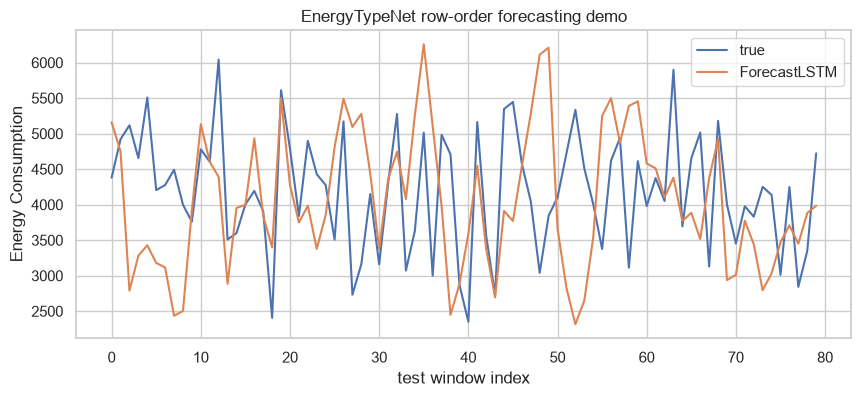

In [10]:
train_df = load_raw(PROJECT_ROOT / 'data' / 'train_energy_data.csv')
test_df = load_raw(PROJECT_ROOT / 'data' / 'test_energy_data.csv')

energy_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
for df in (train_df, test_df):
    df['Is Weekend'] = (df['Day of Week'] == 'Weekend').astype(float)
energy_features.append('Is Weekend')

y_scaler = StandardScaler()
X_scaler = StandardScaler()
X_energy_train = X_scaler.fit_transform(train_df[energy_features].astype(float))
X_energy_test = X_scaler.transform(test_df[energy_features].astype(float))
y_energy_train = y_scaler.fit_transform(train_df[['Energy Consumption']].astype(float)).ravel()
y_energy_test = y_scaler.transform(test_df[['Energy Consumption']].astype(float)).ravel()

def make_feature_windows(X, y, window_size=20):
    Xw, yw = [], []
    for start in range(len(X) - window_size):
        Xw.append(X[start:start + window_size])
        yw.append(y[start + window_size])
    return np.asarray(Xw, dtype=np.float32), np.asarray(yw, dtype=np.float32)[:, None]

Xew_train, yew_train = make_feature_windows(X_energy_train, y_energy_train)
Xew_test, yew_test = make_feature_windows(X_energy_test, y_energy_test)
energy_train_loader = DataLoader(SequenceDataset(Xew_train, yew_train), batch_size=64, shuffle=True)
energy_test_loader = DataLoader(SequenceDataset(Xew_test, yew_test), batch_size=128)

energy_lstm, energy_history, energy_time = train_regressor(
    RecurrentRegressor(kind='lstm', input_size=len(energy_features), hidden_size=40),
    energy_train_loader,
    epochs=35,
)
energy_pred_scaled, energy_true_scaled = predict_regressor(energy_lstm, energy_test_loader)
energy_pred = y_scaler.inverse_transform(energy_pred_scaled).ravel()
energy_true = y_scaler.inverse_transform(energy_true_scaled).ravel()
energy_lstm_mse = mean_squared_error(energy_true, energy_pred)

baseline_X_train = X_energy_train[20:]
baseline_y_train = train_df['Energy Consumption'].astype(float).values[20:]
baseline_X_test = X_energy_test[20:]
baseline_y_test = test_df['Energy Consumption'].astype(float).values[20:]

lin_gd = LinearRegressionGD(learning_rate=0.02, n_iterations=1200).fit(baseline_X_train, baseline_y_train)
ridge = RidgeRegressionCustom(alpha=1.0).fit(baseline_X_train, baseline_y_train)
sk_linear = LinearRegression().fit(baseline_X_train, baseline_y_train)

energy_rows = []
for name, model in [('LinearRegressionGD', lin_gd), ('RidgeRegressionCustom', ridge), ('sklearn LinearRegression', sk_linear)]:
    pred = model.predict(baseline_X_test)
    energy_rows.append({'model': name, 'test_mse': mean_squared_error(baseline_y_test, pred), 'test_mae': mean_absolute_error(baseline_y_test, pred)})
energy_rows.append({'model': 'ForecastLSTM', 'test_mse': energy_lstm_mse, 'test_mae': mean_absolute_error(energy_true, energy_pred)})
energy_df = pd.DataFrame(energy_rows).sort_values('test_mse')
display(energy_df)

plt.figure(figsize=(10, 4))
plt.plot(energy_true, label='true')
plt.plot(energy_pred, label='ForecastLSTM')
plt.title('EnergyTypeNet row-order forecasting demo')
plt.xlabel('test window index')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()


**Observation.** The EnergyTypeNet LSTM trains and produces a valid row-order forecasting demo, but it performs worse than the tabular linear and ridge baselines. Ridge reaches test MSE around `185,145`, while `ForecastLSTM` is around `1,504,594`. That is the correct scientific interpretation: because the dataset has no timestamps, the recurrent model is learning from artificial row order. For real deployment forecasting, the project would need chronological building readings.


## 8. Stacked, Bidirectional and Attention-Augmented LSTMs


,model,test_mse,test_mae,n_params,train_seconds
2,Bidirectional LSTM,0.023528,0.121811,19681,2.366314
3,LSTM + Attention,0.024606,0.123172,17217,1.906948
0,Single LSTM,0.027564,0.137195,17217,1.848950
1,Stacked LSTM,0.027607,0.126395,50497,3.647760


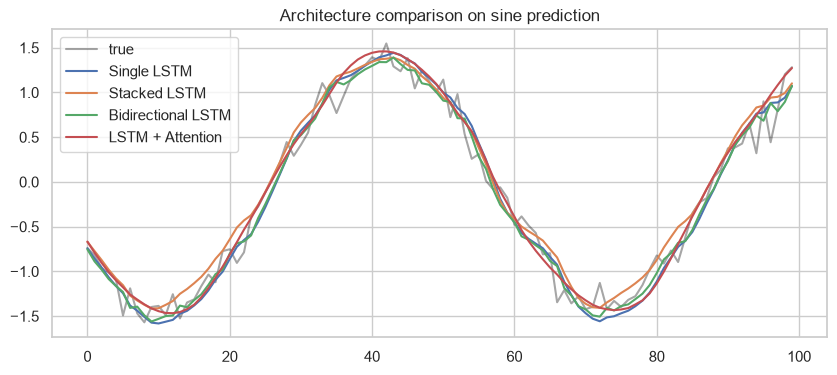

In [11]:
architectures = [
    ('Single LSTM', RecurrentRegressor(kind='lstm', hidden_size=64, num_layers=1)),
    ('Stacked LSTM', RecurrentRegressor(kind='lstm', hidden_size=64, num_layers=2, dropout=0.1)),
    ('Bidirectional LSTM', RecurrentRegressor(kind='lstm', hidden_size=48, bidirectional=True)),
    ('LSTM + Attention', RecurrentRegressor(kind='lstm', hidden_size=64, attention=True)),
]

arch_rows = []
arch_predictions = {}
for name, model in architectures:
    trained, hist, elapsed = train_regressor(model, train_loader, epochs=20)
    metrics = evaluate_regressor(trained, test_loader)
    pred, true = predict_regressor(trained, test_loader)
    arch_predictions[name] = pred[:100].ravel()
    arch_rows.append({
        'model': name,
        'test_mse': metrics['mse'],
        'test_mae': metrics['mae'],
        'n_params': count_params(trained),
        'train_seconds': elapsed,
    })

arch_df = pd.DataFrame(arch_rows).sort_values('test_mse')
display(arch_df)

plt.figure(figsize=(10, 4))
plt.plot(true[:100].ravel(), color='black', alpha=0.35, label='true')
for name, values in arch_predictions.items():
    plt.plot(values, label=name)
plt.title('Architecture comparison on sine prediction')
plt.legend()
plt.show()


**Observation.** In this run, the bidirectional LSTM gives the strongest sine prediction among the LSTM variants with test MSE around `0.0235`. Attention is close at about `0.0246`, while the single and stacked LSTMs are around `0.0276`. The table matters more than the architecture name: it compares error, parameter count and training time so extra complexity has to earn its place.


## 9. Gradient Flow Comparison - RNN vs LSTM vs GRU


,model,sequence_length,grad_at_first_step
0,RNN,10,5.285747e-08
1,RNN,25,1.506101e-17
2,RNN,50,1.020855e-32
3,RNN,100,0.000000e+00
4,RNN,200,0.000000e+00
5,LSTM,10,6.483992e-07
6,LSTM,25,7.609876e-08
7,LSTM,50,1.005515e-12
8,LSTM,100,2.341452e-23
9,LSTM,200,8.247734e-40


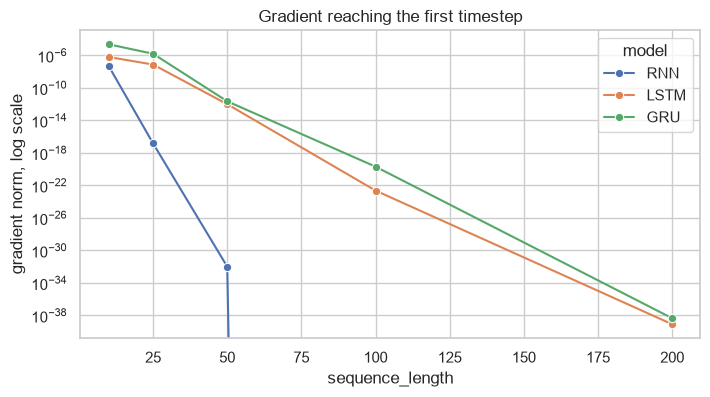

In [12]:
def first_timestep_gradient(kind, seq_len, hidden_size=32):
    model = RecurrentRegressor(kind=kind, hidden_size=hidden_size).to(DEVICE)
    if kind == 'rnn':
        with torch.no_grad():
            model.rnn.weight_hh_l0.mul_(0.45)
    x = torch.tensor(series_scaled[:seq_len], dtype=torch.float32).view(1, seq_len, 1).to(DEVICE)
    x.requires_grad_(True)
    loss = model(x).pow(2).mean()
    loss.backward()
    return x.grad[:, 0, :].norm().item()

lengths = [10, 25, 50, 100, 200]
grad_rows = []
for kind in ['rnn', 'lstm', 'gru']:
    for length in lengths:
        grad_rows.append({'model': kind.upper(), 'sequence_length': length, 'grad_at_first_step': first_timestep_gradient(kind, length)})
grad_df = pd.DataFrame(grad_rows)
display(grad_df)

plt.figure(figsize=(8, 4))
sns.lineplot(data=grad_df, x='sequence_length', y='grad_at_first_step', hue='model', marker='o')
plt.yscale('log')
plt.title('Gradient reaching the first timestep')
plt.ylabel('gradient norm, log scale')
plt.show()


**Observation.** The plain RNN gradient collapses fastest as the sequence gets longer: by length 100, its first-step gradient is already numerically zero. LSTM and GRU also shrink on this diagnostic, but they remain larger for several sequence lengths because their gates create a more controlled memory path.


## 10. Full Comparison Table


In [13]:
full_rows = []
for _, row in comparison_df.iterrows():
    full_rows.append({'model': row['model'], 'type': 'recurrent regressor', 'dataset': 'synthetic sine', 'task': 'one-step forecasting', 'metric': f"MSE={row['test_mse']:.4f}", 'n_params': int(row['n_params']), 'notes': 'baseline recurrent comparison'})
for _, row in arch_df.iterrows():
    full_rows.append({'model': row['model'], 'type': 'LSTM variant', 'dataset': 'synthetic sine', 'task': 'architecture comparison', 'metric': f"MSE={row['test_mse']:.4f}", 'n_params': int(row['n_params']), 'notes': 'complexity vs performance'})
full_rows.append({'model': 'ForecastLSTM', 'type': 'sequence regressor', 'dataset': 'EnergyTypeNet', 'task': 'row-order forecasting demo', 'metric': f"MSE={energy_lstm_mse:.2f}", 'n_params': count_params(energy_lstm), 'notes': 'educational only because rows have no timestamps'})
full_rows.append({'model': 'ClassifierLSTM', 'type': 'bidirectional sequence classifier', 'dataset': 'synthetic sequence classes', 'task': 'sequence classification', 'metric': f"accuracy={cls_acc:.3f}", 'n_params': count_params(classifier), 'notes': 'uses temporal pattern differences'})
full_rows.append({'model': 'RNNCellNumpy', 'type': 'from-scratch recurrent cell', 'dataset': 'synthetic sine', 'task': 'manual BPTT one-step prediction', 'metric': f"MSE={numpy_mse:.4f}", 'n_params': 'manual NumPy weights', 'notes': 'transparent learning mechanics'})

full_df = pd.DataFrame(full_rows)
display(full_df)


,model,type,dataset,task,metric,n_params,notes
0,RNN,recurrent regressor,synthetic sine,one-step forecasting,MSE=0.0223,2497,baseline recurrent comparison
1,GRU,recurrent regressor,synthetic sine,one-step forecasting,MSE=0.0237,37889,baseline recurrent comparison
2,LSTM,recurrent regressor,synthetic sine,one-step forecasting,MSE=0.0241,50497,baseline recurrent comparison
3,Bidirectional LSTM,LSTM variant,synthetic sine,architecture comparison,MSE=0.0235,19681,complexity vs performance
4,LSTM + Attention,LSTM variant,synthetic sine,architecture comparison,MSE=0.0246,17217,complexity vs performance
5,Single LSTM,LSTM variant,synthetic sine,architecture comparison,MSE=0.0276,17217,complexity vs performance
6,Stacked LSTM,LSTM variant,synthetic sine,architecture comparison,MSE=0.0276,50497,complexity vs performance
7,ForecastLSTM,sequence regressor,EnergyTypeNet,row-order forecasting demo,MSE=1504593.88,7561,educational only because rows have no timestamps
8,ClassifierLSTM,bidirectional sequence classifier,synthetic sequence classes,sequence classification,accuracy=1.000,75939,uses temporal pattern differences
9,RNNCellNumpy,from-scratch recurrent cell,synthetic sine,manual BPTT one-step prediction,MSE=0.0424,manual NumPy weights,transparent learning mechanics


## Key Takeaways

- Plain RNNs make hidden-state recurrence visible, but they are vulnerable to vanishing gradients.
- LSTM and GRU gates are practical fixes for longer-range dependencies, even though simple short-horizon tasks may not require them.
- Bidirectional LSTMs are useful for whole-sequence classification when future context is available.
- Attention can help a model choose which hidden states matter, but it should be justified with validation results.
- EnergyTypeNet remains fundamentally tabular; the RNN section demonstrates sequence tooling, while honest forecasting would require true timestamped measurements.
